In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt



# Insert warehouse name here
warehouse_name = "OE"
# Insert user id here
user = "betsyfrdmn"
# GitHub repo
base = "Lucas_Systems_Capstone_Project"

# Load your processed data
df = pd.read_parquet(f"/Users/{user}/{base}/data/processed/oe_detailed.parquet")

Mean Squared Error: 1.0226
R-Squared: 0.2627

Feature Importances:
        Feature  Importance
1  log_distance    0.937522
0    log_weight    0.050101
2         Level    0.012377


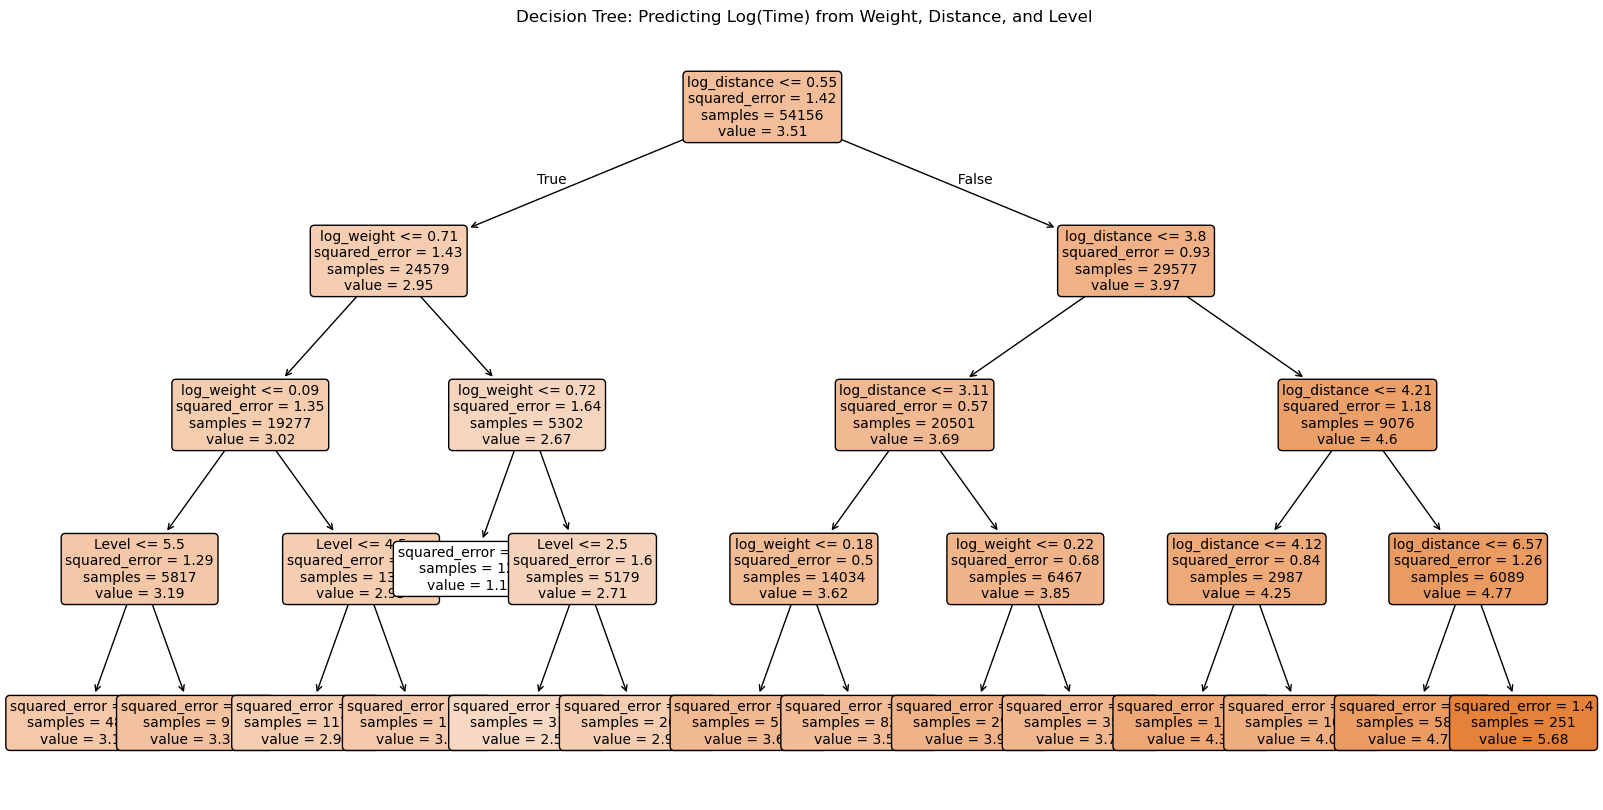

In [47]:
# Filter for only Work Code 30
df = df[df["WorkCode"] == "30"]

# Convert Data Types
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Travel_Distance'] = pd.to_numeric(df['Travel_Distance'], errors='coerce')
df['Time_Delta_sec'] = pd.to_numeric(df['Time_Delta_sec'], errors='coerce')
df['Level'] = pd.to_numeric(df['Level'], errors='coerce')

# Create log transformations (using log1p to handle zeros safely)
df['log_time'] = np.log1p(df['Time_Delta_sec'].fillna(0))
df['log_weight'] = np.log1p(df['Weight'].fillna(0))
df['log_distance'] = np.log1p(df['Travel_Distance'].fillna(0))

# Select Features and Target
features = ['log_weight', 'log_distance', 'Level']
target = 'log_time'

# Drop rows where essential data is missing (e.g., the very first task in a session)
df_model = df.dropna(subset=[target] + features)

X = df_model[features]
y = df_model[target]

# Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Initialize and Train the Decision Tree, max_depth is restricted to 4 so the tree remains readable
model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=4)
model.fit(X_train, y_train)

# Model Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared: {r2:.4f}")

# Visualize the Tree
plt.figure(figsize=(20, 10))
plot_tree(model, 
          feature_names=features, 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10)
plt.title("Decision Tree: Predicting Log(Time) from Weight, Distance, and Level")
plt.savefig('warehouse_decision_tree.png')

# 8. Feature Importance
importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
print("\nFeature Importances:")
print(importance.sort_values(by='Importance', ascending=False))

In [48]:
# 1. Reverse the log transformation
# np.expm1(x) is the inverse of np.log1p(x)
y_test_seconds = np.expm1(y_test)
y_pred_seconds = np.expm1(y_pred)

# 2. Calculate errors in actual seconds
# MAE is often more intuitive than MSE for time
from sklearn.metrics import mean_absolute_error

mae_seconds = mean_absolute_error(y_test_seconds, y_pred_seconds)
rmse_seconds = np.sqrt(mean_squared_error(y_test_seconds, y_pred_seconds))

print(f"--- Performance in Actual Seconds ---")
print(f"Mean Absolute Error: {mae_seconds:.2f} seconds")
print(f"Root Mean Squared Error: {rmse_seconds:.2f} seconds")

# 3. View a few actual vs predicted examples
comparison = pd.DataFrame({
    'Actual_Seconds': y_test_seconds,
    'Predicted_Seconds': y_pred_seconds,
    'Error_Seconds': y_test_seconds - y_pred_seconds
})
print("\nSample Comparisons")
print(comparison.head(10).round(2))

--- Performance in Actual Seconds ---
Mean Absolute Error: 48.44 seconds
Root Mean Squared Error: 186.88 seconds

Sample Comparisons
       Actual_Seconds  Predicted_Seconds  Error_Seconds
35575           34.22              38.48          -4.26
31197          112.82             112.37           0.45
87783           43.25              17.68          25.58
40456           48.81              17.68          31.13
49915           18.62              17.68           0.95
19030           23.83              43.11         -19.28
69117          100.56              49.78          50.78
64497           42.96              38.48           4.48
31757           12.63              11.88           0.76
18573           28.06              17.68          10.38


In [49]:

param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
}
grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 50}


Mean Squared Error: 0.9826
R-Squared: 0.2915

Feature Importances:
        Feature  Importance
1  log_distance    0.847985
0    log_weight    0.118989
2         Level    0.033026


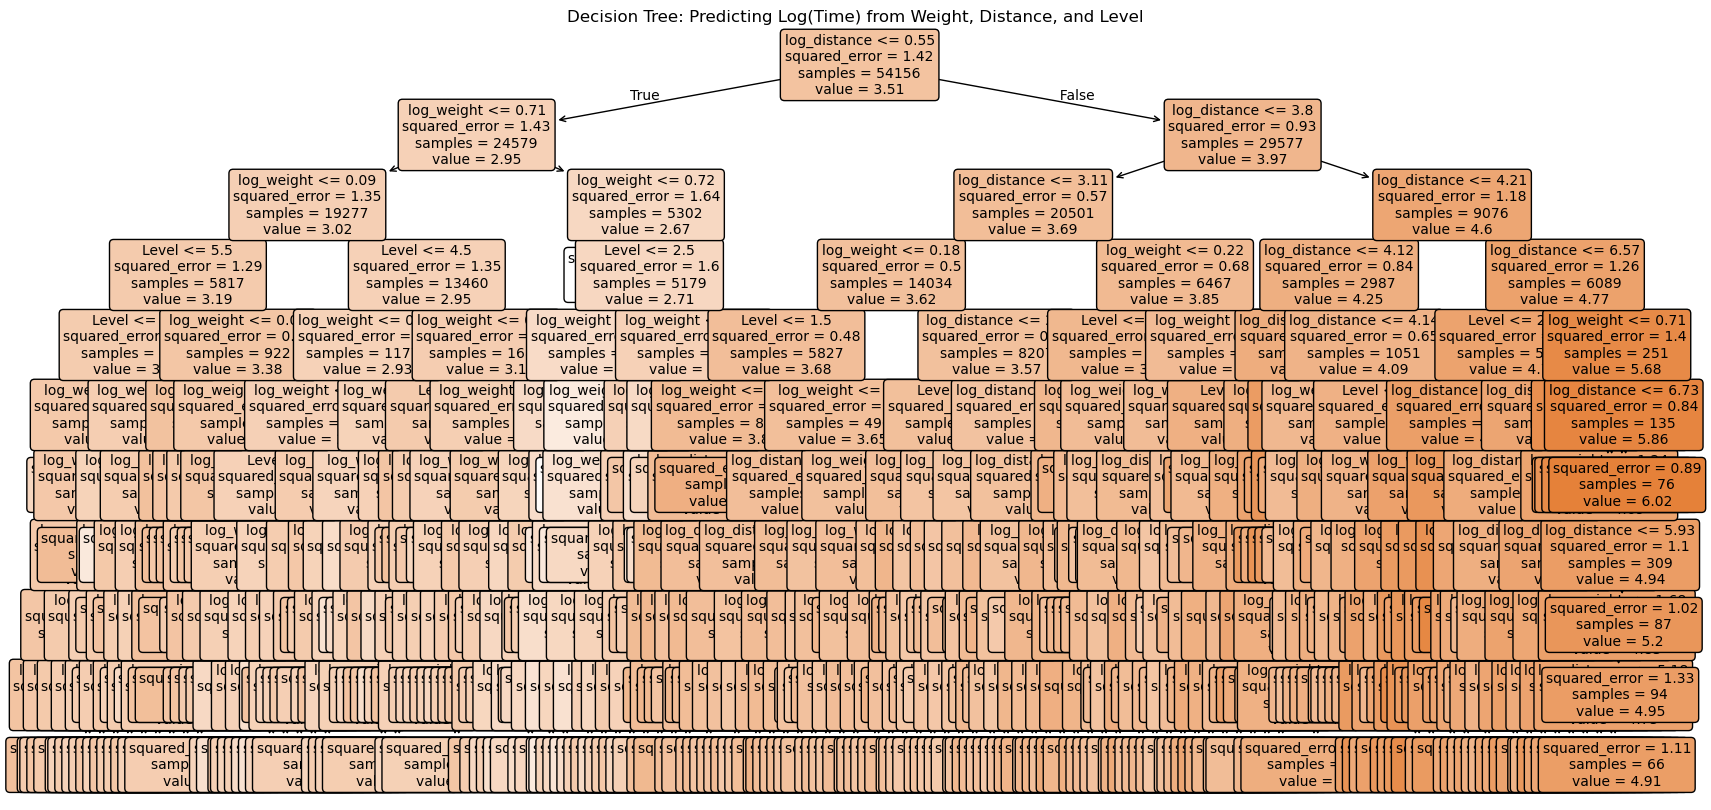

In [50]:
# Convert Data Types
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Travel_Distance'] = pd.to_numeric(df['Travel_Distance'], errors='coerce')
df['Time_Delta_sec'] = pd.to_numeric(df['Time_Delta_sec'], errors='coerce')
df['Level'] = pd.to_numeric(df['Level'], errors='coerce')

# Create log transformations (using log1p to handle zeros safely)
df['log_time'] = np.log1p(df['Time_Delta_sec'].fillna(0))
df['log_weight'] = np.log1p(df['Weight'].fillna(0))
df['log_distance'] = np.log1p(df['Travel_Distance'].fillna(0))

# Select Features and Target
features = ['log_weight', 'log_distance', 'Level']
target = 'log_time'

# Drop rows where essential data is missing (e.g., the very first task in a session)
df_model = df.dropna(subset=[target] + features)

X = df_model[features]
y = df_model[target]

# Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Initialize and Train the Decision Tree, max_depth is restricted to 4 so the tree remains readable
model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, random_state=4)
model.fit(X_train, y_train)

# Model Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared: {r2:.4f}")

# Visualize the Tree
plt.figure(figsize=(20, 10))
plot_tree(model, 
          feature_names=features, 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10)
plt.title("Decision Tree: Predicting Log(Time) from Weight, Distance, and Level")
plt.savefig('warehouse_decision_tree.png')

# 8. Feature Importance
importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
print("\nFeature Importances:")
print(importance.sort_values(by='Importance', ascending=False))

In [51]:
# 1. Reverse the log transformation for both actual and predicted values
y_test_seconds = np.expm1(y_test)
y_pred_seconds = np.expm1(y_pred)

# 2. Calculate standard metrics in seconds
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_seconds = mean_absolute_error(y_test_seconds, y_pred_seconds)
rmse_seconds = np.sqrt(mean_squared_error(y_test_seconds, y_pred_seconds))

print(f"Results in Actual Seconds (Max Depth 10)")
print(f"\nMean Absolute Error (MAE): {mae_seconds:.2f} seconds")
print(f"Root Mean Squared Error (RMSE): {rmse_seconds:.2f} seconds")

# 3. Quick comparison of logs vs. seconds
results_df = pd.DataFrame({
    'Actual_Log': y_test,
    'Pred_Log': y_pred,
    'Actual_Secs': y_test_seconds,
    'Pred_Secs': y_pred_seconds
}).head(10)

print("\n\nSample Comparisons:")
print(results_df.round(2))

Results in Actual Seconds (Max Depth 10)

Mean Absolute Error (MAE): 47.80 seconds
Root Mean Squared Error (RMSE): 185.23 seconds


Sample Comparisons:
       Actual_Log  Pred_Log  Actual_Secs  Pred_Secs
35575        3.56      3.77        34.22      42.36
31197        4.73      4.68       112.82     106.55
87783        3.79      3.00        43.25      19.06
40456        3.91      3.00        48.81      19.06
49915        2.98      2.96        18.62      18.32
19030        3.21      3.83        23.83      45.29
69117        4.62      4.03       100.56      55.38
64497        3.78      3.69        42.96      39.19
31757        2.61      2.67        12.63      13.50
18573        3.37      2.85        28.06      16.33
